In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Iris dataset load karo
iris = load_iris()
X = iris.data        # Features: sepal length, sepal width, petal length, petal width
y = iris.target      # Labels: 0=Setosa, 1=Versicolor, 2=Virginica

# Dataset samjho
print("Shape:", X.shape)        # (150, 4)
print("Classes:", iris.target_names)
print(pd.DataFrame(X, columns=iris.feature_names).head())

Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Ab mean=0, variance=1 ho jayega

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42,    # reproducibility ke liye
    shuffle=True        # order bias hatao
)

print("Training samples:", X_train.shape[0])   # 120
print("Testing samples:", X_test.shape[0])     # 30

Training samples: 120
Testing samples: 30


In [5]:
# INSTANTIATE
model = KNeighborsClassifier(n_neighbors=5)

# FIT (train karo)
model.fit(X_train, y_train)

# PREDICT (test karo)
predictions = model.predict(X_test)

F1 Score: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



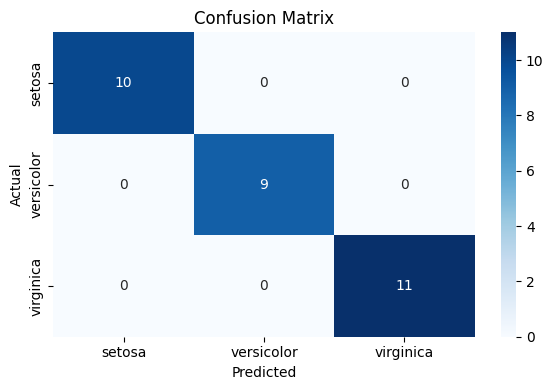

In [6]:
# F1 Score (PDF mein yahi required tha)
f1 = f1_score(y_test, predictions, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Classification Report
print(classification_report(y_test, predictions, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

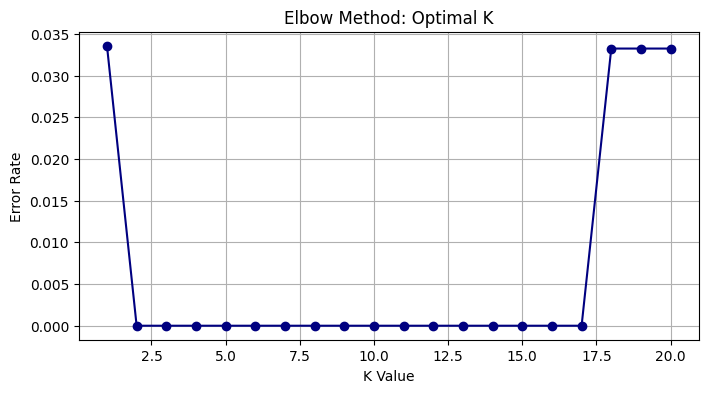

In [7]:
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - f1_score(y_test, preds, average='weighted'))

plt.figure(figsize=(8,4))
plt.plot(range(1, 21), error_rates, marker='o', color='navy')
plt.title('Elbow Method: Optimal K')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()